# Smolagents

In [1]:
!python -m pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [2]:
!pip install smolagents

In [3]:
!pip install "smolagents[toolkit]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 44.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 31.5 MB/s  0:00:00
  Attempting uninstall: lxml
    Found existing installation: lxml 5.4.0
    Uninstalling lxml-5.4.0:
      Successfully uninstalled lxml-5.4.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [ddgs]


In [4]:
! pip install litellm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 45.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [litellm]


In [5]:
!pip install -U transformers datasets evaluate accelerate timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 52.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 49.1 MB/s  0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: timm
    Found existing installation: timm 1.0.21
    Uninstalling timm-1.0.21:
      Successfully uninstalled timm-1.0.21
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [evaluate]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
pylibcudf-cu12 2

# Kodēšanas aģenti (Code Agents)

In [1]:
import os
from google.colab import userdata
os.environ['GEMINI_API_KEY']=userdata.get('GOOGLE_API_KEY')

In [2]:
from smolagents import LiteLLMModel
model = LiteLLMModel(model_id="gemini/gemini-2.0-flash")

In [ ]:
from smolagents import CodeAgent, DuckDuckGoSearchTool
agent = CodeAgent(tools=[DuckDuckGoSearchTool()], model=model)

In [ ]:
agent.run("What is the cube root of 27?")

In [ ]:
agent.run("How long does it take to drive from Melbourne to Sydney?")

In [ ]:
agent = CodeAgent(tools=[DuckDuckGoSearchTool()], model=model, additional_authorized_imports=[ 'math','pandas','requests', 'bs4', 'requests.exceptions', 'json'])

In [ ]:
agent.run("What year should I have bought bitcoin to invest $1000 and now have 1 million dollars?")

In [ ]:
agent.run("What are the today`s five news topics on Google News?")

# Transformētāju rīki (Transformer tools)

In [ ]:
from smolagents import Tool, CodeAgent
from transformers import pipeline

# Create the Hugging Face pipeline
classifier = pipeline("sentiment-analysis")

# Define a proper Tool with the new input schema
class SentimentTool(Tool):
    name = "sentiment_tool"
    description = "Analyzes the sentiment of text using a Hugging Face Transformers model."
    inputs = {
        "text": {
            "type": "string",
            "description": "Text to analyze for sentiment."
        }
    }
    output_type = "string"

    def forward(self, text: str):
        result = classifier(text)[0]
        label = result["label"]
        score = round(result["score"], 3)
        return f"{label} (confidence={score})"

# Create the agent  —  NOTE: no `verbosity` argument now
agent = CodeAgent(
    tools=[SentimentTool()],
    model=model,
    max_steps=3
)

# Run it
agent.run("Use sentiment_tool to analyze this sentence: 'I've been waiting for a HuggingFace course my whole life!'")

# Rīks no HF Spaces (Tool from HF Spaces)

HF Spaces https://huggingface.co/spaces

Loaded as API: https://black-forest-labs-flux-1-schnell.hf.space ✔


/usr/local/lib/python3.12/dist-packages/smolagents/tools.py:666: UserWarning: Since `api_name` was not defined, it was automatically set to the first available API: `/infer`.
  warnings.warn(


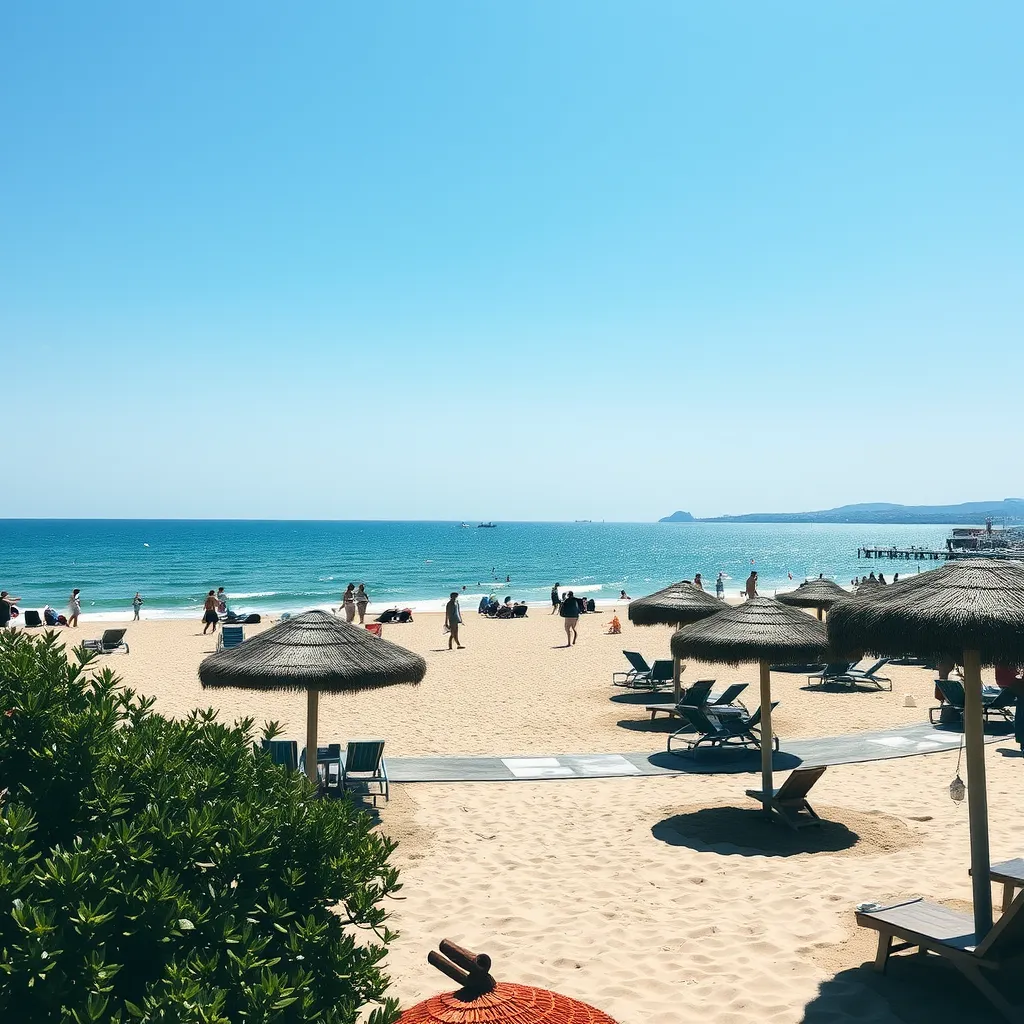

In [ ]:
from smolagents import Tool
from PIL import Image
import io

from IPython.display import Image as DisplayImage

image_generation_tool = Tool.from_space(
    "black-forest-labs/FLUX.1-schnell",
    name="image_generator",
    description="Generate an image from a prompt"
)

# The tool returns a PIL Image object
generated_image = image_generation_tool("A sunny beach")

# Save the image to a byte buffer in PNG format
buffer = io.BytesIO()
generated_image.save(buffer, format="PNG")
buffer.seek(0)

# Display the image from the buffer

DisplayImage(buffer.getvalue(), format='png')

In [ ]:
from smolagents import Tool, LiteLLMModel, CodeAgent
import gradio as gr

# Load image generation tool (Hugging Face Space)
image_tool = Tool.from_space(
    "black-forest-labs/FLUX.1-schnell",
    name="image_generator",
    description="Generate an image from a prompt"
)

# Gemini model for prompt improvement
model = LiteLLMModel(model_id="gemini/gemini-2.5-flash")
agent = CodeAgent(tools=[image_tool], model=model)

# Simple Gradio wrapper
def generate(prompt):
    result = agent.run(f"Improve this prompt: '{prompt}' and generate the image.")
    # agent returns the PIL Image directly (from the tool)
    return result if hasattr(result, "save") else None

# Launch Gradio app
gr.Interface(
    fn=generate,
    inputs="text",
    outputs="image",
    title="🎨 Gemini + FLUX Image Generator",
    description="Improves your prompt with Gemini and generates an image using FLUX.1-schnell"
).launch()


Loaded as API: https://black-forest-labs-flux-1-schnell.hf.space ✔


/usr/local/lib/python3.12/dist-packages/smolagents/tools.py:666: UserWarning: Since `api_name` was not defined, it was automatically set to the first available API: `/infer`.
  warnings.warn(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ffd6a7339d50b48022.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# LangChain rīki (LangChain Tools)

In [8]:
import os
import pprint

!pip install -qU langchain-community langchain

os.environ["SERPER_API_KEY"] = userdata.get('SERPER_API_KEY')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


# SerperDev

In [3]:
import os
import pprint

os.environ["SERPER_API_KEY"] = userdata.get('SERPER_API_KEY')

In [4]:
from langchain.tools import tool, ToolRuntime
from langchain_community.utilities import GoogleSerperAPIWrapper
from smolagents import Tool as SmolTool, CodeAgent

# Initialize API wrapper
search_api = GoogleSerperAPIWrapper()

@tool("google_serper_search", description="Search Google via the Serper API")
def google_serper_search(query: str) -> str:
    """Search the web for information using Serper API."""
    return search_api.run(query)

# Wrap for SmolAgents
serper_tool = SmolTool.from_langchain(google_serper_search)

In [5]:
agent = CodeAgent(tools=[serper_tool], model=model)

agent.run("How many more blocks (also denoted as layers) are in BERT base encoder compared to the encoder from the architecture proposed in Attention is All You Need?")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ How many more blocks (also denoted as layers) are in BERT base encoder compared to the encoder from the         │
│ architecture proposed in Attention is All You Need?                                                             │
│                                                                                                                 │
╰─ LiteLLMModel - gemini/gemini-2.0-flash ────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  bert_layers_query = "number of layers in BERT base"                                                              
  attention_layers_query = "number of layers in transformer Attention is All You Need"                             
                                                                                                                   
  bert_layers_result = google_serper_search(query=bert_layers_query)                                               
  attention_layers_result = google_serper_search(query=attention_layers_query)                                     
                                                                                                                   
  print(bert_layers_result)                                                                                        
  print(attention_layers_result)                                                                                   
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
The BERTBase model uses 12 layers of transformers block with a hidden size of 768 and number of self-attention 
heads as 12 and has around 110M trainable parameters. Sep 12, 2023
In this work we employ h = 8 parallel attention layers, or heads. For each of these we use dk = dv = dmodel/h = 64.
Due to the reduced dimension of each head, the total computational cost is similar to that of single-head attention
with full dimensionality.

Out: None

[Step 1: Duration 4.68 seconds| Input tokens: 2,204 | Output tokens: 177]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  difference = 12 - 6                                                                                              
  final_answer(difference)                                                                                         
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: 6

[Step 3: Duration 1.01 seconds| Input tokens: 7,789 | Output tokens: 354]

6

## FileManagementToolkit

In [ ]:
from langchain_community.agent_toolkits import FileManagementToolkit

# We'll make a temporary directory to avoid clutter
working_directory = "/content/sample_data"

In [ ]:
toolkit = FileManagementToolkit(
    root_dir=str(working_directory)
)  # If you don't provide a root_dir, operations will default to the current working directory
toolkit.get_tools()

[CopyFileTool(root_dir='/content/sample_data'),
 DeleteFileTool(root_dir='/content/sample_data'),
 FileSearchTool(root_dir='/content/sample_data'),
 MoveFileTool(root_dir='/content/sample_data'),
 ReadFileTool(root_dir='/content/sample_data'),
 WriteFileTool(root_dir='/content/sample_data'),
 ListDirectoryTool(root_dir='/content/sample_data')]

In [ ]:
from smolagents import Tool
from langchain_community.agent_toolkits import FileManagementToolkit

langchain_tools = FileManagementToolkit(
    root_dir=str(working_directory),
    selected_tools=["list_directory"],
).get_tools()

dir_tool = [Tool.from_langchain(tool) for tool in langchain_tools]
dir_tool

[<smolagents.tools.Tool.from_langchain.<locals>.LangChainToolWrapper at 0x7ba394fd3bc0>]

In [ ]:
from smolagents import Tool, CodeAgent, LiteLLMModel

model = LiteLLMModel(model_id="gemini/gemini-2.5-flash")

agent = CodeAgent(tools=dir_tool, model=model)

In [ ]:
result=agent.run("List the files in the current directory.")
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ List the files in the current directory.                                                                        │
│                                                                                                                 │
╰─ LiteLLMModel - gemini/gemini-2.5-flash ────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  print(list_directory(dir_path="."))                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
anscombe.json
README.md
mnist_test.csv
california_housing_test.csv
california_housing_train.csv
mnist_train_small.csv

Out: None

[Step 1: Duration 1.21 seconds| Input tokens: 2,195 | Output tokens: 60]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("The files in the current directory are: anscombe.json, README.md, mnist_test.csv,                  
  california_housing_test.csv, california_housing_train.csv, mnist_train_small.csv")                               
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: The files in the current directory are: anscombe.json, README.md, mnist_test.csv, 
california_housing_test.csv, california_housing_train.csv, mnist_train_small.csv

[Step 2: Duration 1.12 seconds| Input tokens: 4,511 | Output tokens: 182]

The files in the current directory are: anscombe.json, README.md, mnist_test.csv, california_housing_test.csv, california_housing_train.csv, mnist_train_small.csv


# Daudzagentu sistēmas (Multi-agent systems)

## Piemērs 1

In [ ]:
import re
import requests
from markdownify import markdownify
from requests.exceptions import RequestException
from smolagents import tool


@tool
def visit_webpage(url: str) -> str:
    """Visits a webpage at the given URL and returns its content as a markdown string.

    Args:
        url: The URL of the webpage to visit.

    Returns:
        The content of the webpage converted to Markdown, or an error message if the request fails.
    """
    try:
        # Send a GET request to the URL
        response = requests.get(url)
        response.raise_for_status()  # Raise an exception for bad status codes

        # Convert the HTML content to Markdown
        markdown_content = markdownify(response.text).strip()

        # Remove multiple line breaks
        markdown_content = re.sub(r"\n{3,}", "\n\n", markdown_content)

        return markdown_content

    except RequestException as e:
        return f"Error fetching the webpage: {str(e)}"
    except Exception as e:
        return f"An unexpected error occurred: {str(e)}"

In [ ]:
print(visit_webpage("https://www.crewai.com/")[:500])

In [ ]:
from smolagents import (
    CodeAgent,
    ToolCallingAgent,
    InferenceClientModel,
    WebSearchTool,
    LiteLLMModel,
)

from smolagents import LiteLLMModel

model = LiteLLMModel(model_id="gemini/gemini-2.5-flash")

web_agent = ToolCallingAgent(
    tools=[WebSearchTool(), visit_webpage],
    model=model,
    max_steps=10,
    name="web_search_agent",
    description="Runs web searches for you.",
)

In [ ]:
manager_agent = CodeAgent(
    tools=[],
    model=model,
    managed_agents=[web_agent],
    additional_authorized_imports=["time", "numpy", "pandas"],
)

In [ ]:
answer = manager_agent.run("If LLM training continues to scale up at the current rhythm until 2030, what would be the electric power in GW required to power the biggest training runs by 2030? What would that correspond to, compared to some countries? Please provide a source for any numbers used.")

## Piemērs 2

In [ ]:
from smolagents import (
    CodeAgent,
    ToolCallingAgent,
    LiteLLMModel,
    WebSearchTool,
    tool,
)
import requests
import re
from markdownify import markdownify
from requests.exceptions import RequestException

# Step 1: Initialize the LLM
model = LiteLLMModel(model_id="gemini/gemini-2.5-flash")

# Step 2: Define the webpage tool with proper docstring
@tool
def visit_webpage(url: str) -> str:
    """
    Visits a webpage and returns its content as Markdown.

    Args:
        url (str): The URL of the webpage to visit.

    Returns:
        str: The content of the webpage converted to Markdown, or an error message if fetching fails.
    """
    try:
        response = requests.get(url, timeout=5)
        response.raise_for_status()
        markdown_content = markdownify(response.text).strip()
        markdown_content = re.sub(r"\n{3,}", "\n\n", markdown_content)
        return markdown_content
    except RequestException as e:
        return f"Error fetching the webpage: {str(e)}"
    except Exception as e:
        return f"Unexpected error: {str(e)}"

# Step 3: Web search agent
web_agent = ToolCallingAgent(
    tools=[WebSearchTool(), visit_webpage],
    model=model,
    max_steps=5,
    name="web_search_agent",
    description="Searches DuckDuckGo for financial market news and fetches URLs.",
)

# Step 4: Content extraction agent (uses visit_webpage)
content_agent = ToolCallingAgent(
    tools=[visit_webpage],
    model=model,
    max_steps=5,
    name="content_agent",
    description="Extracts main text from URLs.",
)

# Step 5: Summarization agent
summarization_agent = ToolCallingAgent(
    tools=[],
    model=model,
    max_steps=5,
    name="summarization_agent",
    description="Summarizes financial news articles.",
)

# Step 6: Manager agent orchestrates all
manager_agent = CodeAgent(
    tools=[],
    model=model,
    managed_agents=[web_agent, content_agent, summarization_agent],
    additional_authorized_imports=["time", "numpy", "pandas", "requests", "re", "markdownify"],
    name="manager_agent",
    description="Orchestrates searching, extraction, and summarization of financial news."
)

# Step 7: Run the system
query = "latest financial market news October 2025"
summary = manager_agent.run(
    f"Search the internet for '{query}', extract the main content of the top articles, and summarize the latest trends in financial markets."
)

print(summary)